In [ ]:
import transformers
from transformers import pipeline
from nltk import sent_tokenize
import nltk

In [ ]:
nltk.download('punkt')

# 1. Load model

In [ ]:
import torch

In [ ]:
model_name = "facebook/bart-large-mnli"
device = 0 if torch.cuda.is_available() else 'cpu'

In [ ]:
def load_model(device):
  theme_classifier = pipeline(
    "zero-shot-classification",
    model=model_name,
    device=device
  )

  return theme_classifier

In [ ]:
theme_classifier = load_model(device)

In [ ]:
theme_list = ["friendship","hope","sacrifice","battle","self development","betrayal","love","dialogue"]

In [ ]:
theme_classifier(
  "I gave him a right hook then a left jab",
  theme_list,
  multi_label=True
)

# 2. Load dataset

In [ ]:
from glob import glob

In [ ]:
files = glob("../data/Subtitles/*.ass")
files[:5]

In [ ]:
with open(files[0], 'r', encoding='utf-8') as f:
  content = f.readlines()
  content = content[27:]
  content = [",".join(cont.split(',')[9:]) for cont in content]
  # print(content[27:])

In [ ]:
content[:5]

In [ ]:
# replacing the \N with space
content = [cont.replace('\\N', ' ') for cont in content]
content[:5]

In [ ]:
# combing sentences into paragraphs
" ".join(content[:10])

In [ ]:
# extracting the episode number
int(files[0].split('-')[-1].split('.')[0].strip())

In [ ]:
import pandas as pd

In [ ]:
def load_subtitles_dataset(dataset_path):
  subtitles_paths = glob(dataset_path+'/*.ass')

  scripts=[]
  episode_num=[]

  for path in subtitles_paths:

    #Read Lines
    with open(path,'r') as file:
      lines = file.readlines()
      lines = lines[27:]
      lines =  [ ",".join(line.split(',')[9:])  for line in lines ]
    
    lines = [ line.replace('\\N',' ') for line in lines]
    script = " ".join(lines)

    episode = int(path.split('-')[-1].split('.')[0].strip())

    scripts.append(script)
    episode_num.append(episode)

  df = pd.DataFrame.from_dict({"episode":episode_num, "script":scripts })
  return df

In [ ]:
data = load_subtitles_dataset("../data/Subtitles")
data.head()

## Run the model

In [ ]:
script = data.iloc[0]['script']
script

In [ ]:
script_sentences = sent_tokenize(script)
script_sentences[:3]

In [ ]:
# Batch Sentence
sentence_batch_size=20
script_batches = []
for index in range(0,len(script_sentences),sentence_batch_size):
  sent = " ".join(script_sentences[index:index+sentence_batch_size])
  script_batches.append(sent)

In [ ]:
script_batches[:2]

In [ ]:
theme_output = theme_classifier(
  script_batches[:2],
  theme_list,
  multi_label=True
)

In [ ]:
theme_output

In [ ]:
# Wrangle Ouput
# battle: [0.51489498, 0.2156498]
themes = {}
for output in theme_output:
  for label,score in zip(output['labels'],output['scores']):
    if label not in themes:
      themes[label] = []
    themes[label].append(score)

In [ ]:
themes

In [ ]:
import numpy as np

In [ ]:
def get_themes_inference(script):
  script_sentences = sent_tokenize(script)

  # Batch Sentence
  sentence_batch_size=20
  script_batches = []
  for index in range(0,len(script_sentences),sentence_batch_size):
    sent = " ".join(script_sentences[index:index+sentence_batch_size])
    script_batches.append(sent)
  
  # Run Model
  theme_output = theme_classifier(
    script_batches[:2],
    theme_list,
    multi_label=True
  )

  # Wrangle Output 
  themes = {}
  for output in theme_output:
    for label,score in zip(output['labels'],output['scores']):
      if label not in themes:
        themes[label] = []
      themes[label].append(score)

  themes = {key: np.mean(np.array(value)) for key,value in themes.items()}

  return themes

In [ ]:
output_themes = data['script'].apply(get_themes_inference)
output_themes

In [ ]:
theme_df = pd.DataFrame(output_themes.tolist())
theme_df.head()

In [ ]:
data[theme_df.columns] = theme_df
data.head()

# Visualize the output

In [ ]:
# data = data.drop('dialogue',axis=1)
data.head()

In [ ]:
theme_output = data.drop(['episode', 'script'], axis=1).sum().reset_index()
theme_output.columns = ['theme', 'score']
theme_output

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

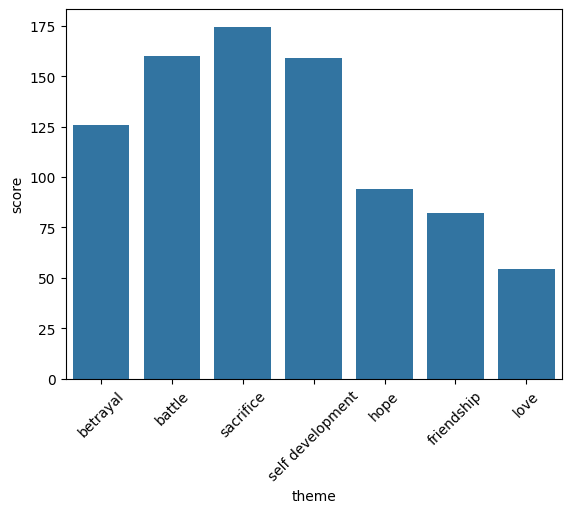

In [46]:
sns.barplot(data = theme_output ,x="theme",y="score" )
plt.xticks(rotation=45)
plt.show()